In [ ]:
# packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# **2. data preprocessing**

Original size: 1197998, After removing outliers: 1194593


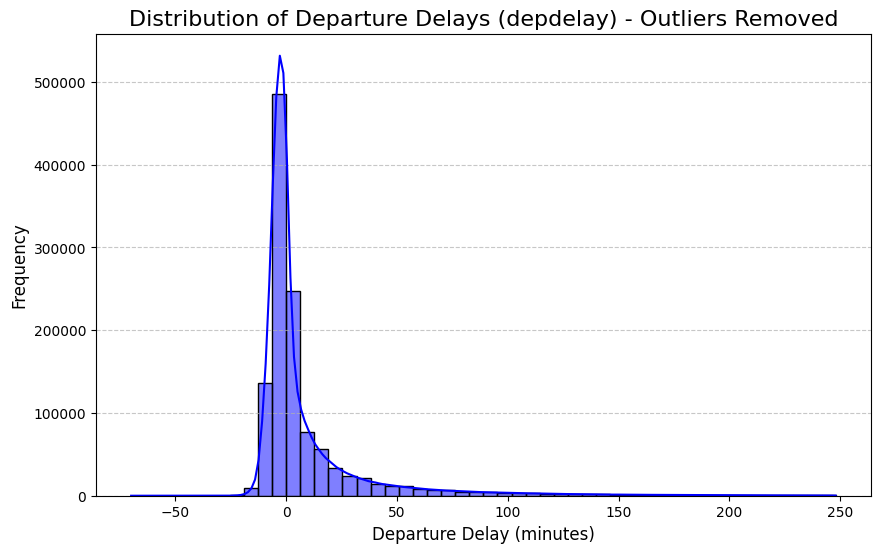

In [ ]:
file_path = 'DelayData.csv'
flight_data = pd.read_csv(file_path)
# Drop null values & duplicated columns
flight_data = flight_data.dropna().drop(columns=['arrdelay', 'tailnum', 'origin', 'dest', 'origincityname', 'originstate', 'windspeedsquare',
                                                 'temp_ninfty_n10', 'temp_n10_0', 'temp_0_10', 'temp_10_20', 'temp_20_30', 'temp_30_40', 'temp_40_infty',
                                                 'nonhubairportorigin', 'nonhubairportdest', 'nonhubairlineorigin', 'nonhubairlinedest'])
#Target Encoding Categorical variables
carrier_encoded = flight_data.groupby('uniquecarrier')['depdelay'].mean()
flight_data['uniquecarrier'] = flight_data['uniquecarrier'].map(carrier_encoded)
orig_encoded = flight_data.groupby('originairportid')['depdelay'].mean()
flight_data['originairportid'] = flight_data['originairportid'].map(orig_encoded)
orig_encoded = flight_data.groupby('originairportid')['depdelay'].mean()
flight_data['originairportid'] = flight_data['originairportid'].map(orig_encoded)
flight_data['scheduleddepartdatetime'] = pd.to_datetime(flight_data['scheduleddepartdatetime'], format='%d-%b-%Y %H:%M:%S', errors='coerce')
flight_data['minute'] = flight_data['scheduleddepartdatetime'].dt.minute
flight_data = flight_data.drop(columns=['scheduleddepartdatetime'])
# Remove outliers
Q1 = flight_data['depdelay'].quantile(0.25)
Q3 = flight_data['depdelay'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 10 * IQR
upper_bound = Q3 + 20 * IQR
filtered_data = flight_data[(flight_data['depdelay'] >= lower_bound) & (flight_data['depdelay'] <= upper_bound)]
print(f"Original size: {len(flight_data)}, After removing outliers: {len(filtered_data)}")
# Plot distribution
plt.figure(figsize=(10, 6))
sns.histplot(filtered_data['depdelay'], bins=50, kde=True, color='blue')
plt.title('Distribution of Departure Delays (depdelay) - Outliers Removed', fontsize=16)
plt.xlabel('Departure Delay (minutes)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

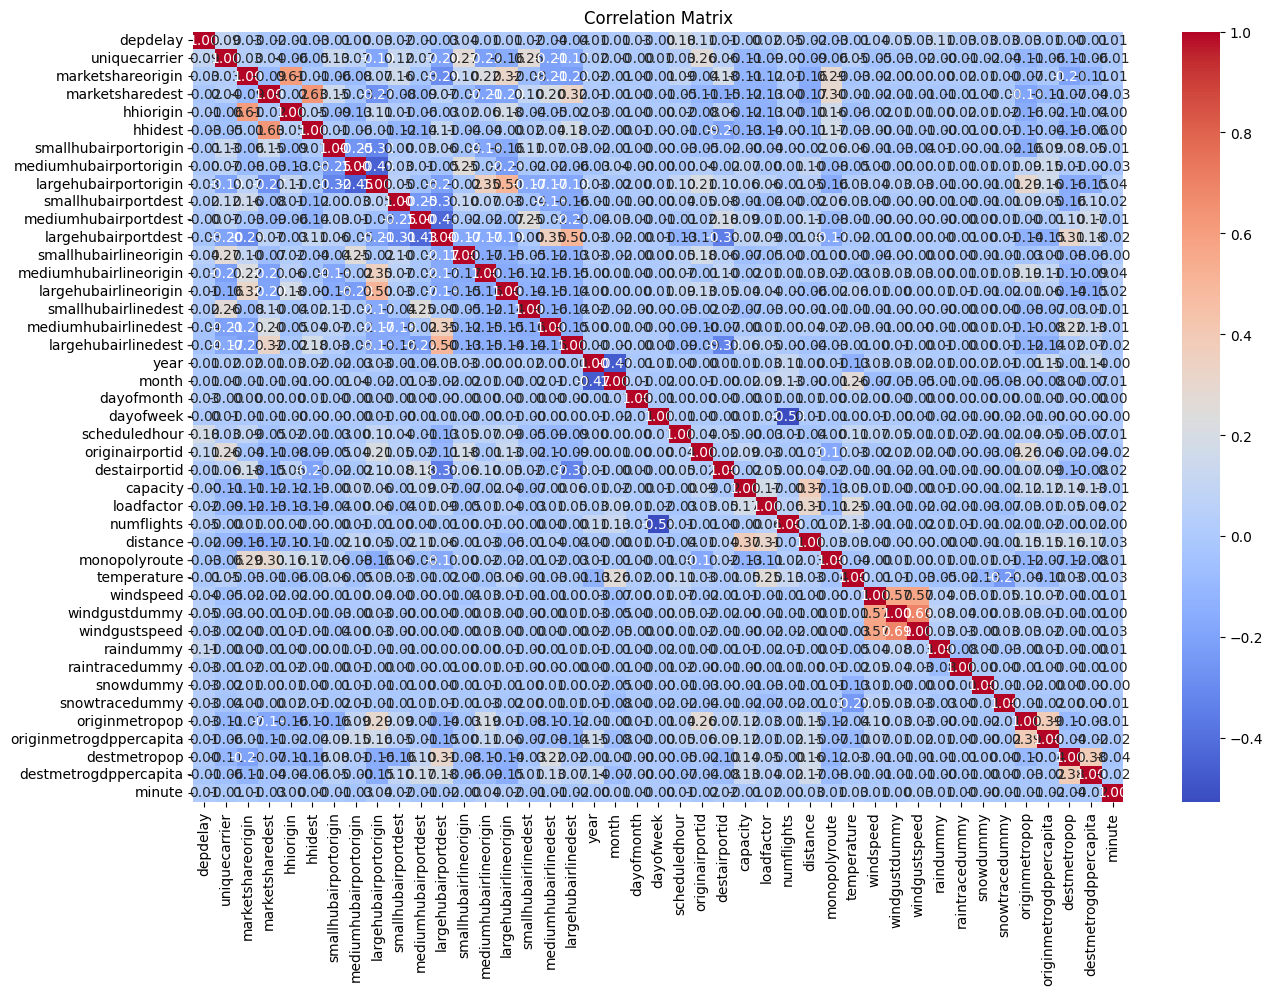

In [ ]:
# Check correlation(all ｜c｜< 0.8)
correlation_matrix = filtered_data.corr()
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# Check Multicollinearity(VIF < 5)
X = filtered_data
X = add_constant(X)
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

                    Feature           VIF
0                     const  2.590532e+07
1                  depdelay  1.077206e+00
2             uniquecarrier  1.696231e+00
3         marketshareorigin  3.317891e+00
4           marketsharedest  3.441454e+00
5                 hhiorigin  1.976788e+00
6                   hhidest  2.160061e+00
7     smallhubairportorigin  1.776543e+00
8    mediumhubairportorigin  2.928217e+00
9     largehubairportorigin  5.658899e+00
10      smallhubairportdest  1.741786e+00
11     mediumhubairportdest  2.808480e+00
12      largehubairportdest  5.550217e+00
13    smallhubairlineorigin  1.821227e+00
14   mediumhubairlineorigin  2.853769e+00
15    largehubairlineorigin  3.549278e+00
16      smallhubairlinedest  1.756238e+00
17     mediumhubairlinedest  2.747268e+00
18      largehubairlinedest  3.507933e+00
19                     year  1.449560e+00
20                    month  1.425797e+00
21               dayofmonth  1.002122e+00
22                dayofweek  1.419

In [ ]:
# Train/test split
X = filtered_data.drop(columns=['depdelay'])
y = filtered_data['depdelay']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)
y_train_binary = (y_train > 0).astype(int)
y_test_binary = (y_test > 0).astype(int)

# **3. setup classification models**

In [ ]:
# Baseline
baseline_1_acc = (y_test_binary == 0).sum() / len(y_test_binary)
print(f'Baseline Test Accuracy: {baseline_1_acc:.4f}')

Baseline Test Accuracy: 0.6449


# **Logistic**

In [ ]:
# Logistic before PCA
model = sm.Logit(y_train_binary, X_train)
result = model.fit()
print(result.summary())
y_test_pred_prob = result.predict(X_test)
y_pred_logistic = (y_test_pred_prob > 0.5).astype(int)
accuracy = accuracy_score(y_test_binary, y_pred_logistic)
print(f"Logistic Test Accuracy: {accuracy:.4f}")
print("Logistic Model Confusion Matrix:")
print(confusion_matrix(y_test_binary, y_pred_logistic))

Optimization terminated successfully.
         Current function value: 0.625195
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:               depdelay   No. Observations:               955674
Model:                          Logit   Df Residuals:                   955631
Method:                           MLE   Df Model:                           42
Date:                Thu, 19 Dec 2024   Pseudo R-squ.:                 0.06438
Time:                        03:44:13   Log-Likelihood:            -5.9748e+05
converged:                       True   LL-Null:                   -6.3860e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -6.9450      2.031     -3.419      0.001     -10.926   

# **CART**

Fitting 5 folds for each of 20 candidates, totalling 100 fits
CART Model Accuracy: 0.6754953360114387
CART Model Confusion Matrix:
[[8545  927]
 [4078 1137]]


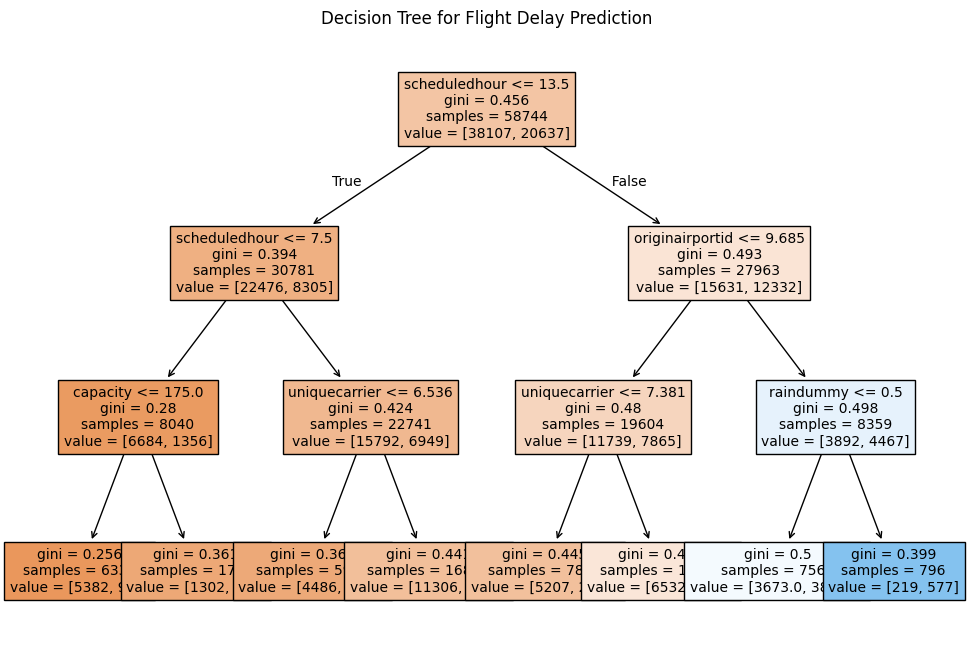

In [ ]:
# CART

from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import numpy as np
from sklearn.model_selection import GridSearchCV

cart = DecisionTreeClassifier(random_state = 2024,
    max_depth=3,
    min_samples_split=20,
    min_samples_leaf=10)

param_grid = {'ccp_alpha': np.linspace(0, 0.1, 20)}

cart_gridscv = GridSearchCV(estimator = cart, param_grid = param_grid, cv=5, scoring='accuracy', verbose=1)
cart_gridscv.fit(X_train, y_train_binary)
best_params = cart_gridscv.best_params_
best_cart = cart_gridscv.best_estimator_
y_pred_cart = best_cart.predict(X_test)

accuracy_cart = accuracy_score(y_test_binary, y_pred_cart)
print("CART Model Accuracy:", accuracy)
print("CART Model Confusion Matrix:")
print(confusion_matrix(y_test_binary, y_pred_cart))

# plot CART decision tree
plt.figure(figsize=(12, 8))
plot_tree(best_cart, filled=True, feature_names=X_test.columns, fontsize=10)
plt.title('Decision Tree for Flight Delay Prediction')
plt.show()

# **random forest**

In [ ]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=2024,
                            min_samples_leaf=5)

grid_values = {'max_features': [1, 2, 3],
               'min_samples_leaf': [5],
               'n_estimators': [10],
               'random_state': [2024]}
rf_cv = GridSearchCV(estimator = rf, param_grid = grid_values, cv=5, scoring='accuracy', verbose=1)

rf_cv.fit(X_train, y_train_binary)
best_params_rf = rf_cv.best_params_

best_rf = rf_cv.best_estimator_
y_pred_rf = best_rf.predict(X_test)

accuracy_rf = accuracy_score(y_test_binary, y_pred_rf)
print("Random Forest Model Accuracy:", accuracy_rf)
print("Random Forest Model Confusion Matrix:")
print(confusion_matrix(y_test_binary, y_pred_rf))

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Random Forest Model Accuracy: 0.6632373314805436
Random Forest Model Confusion Matrix:
[[120702  25003]
 [ 55456  37758]]


# **Gradient descent**

In [ ]:
# gradient descent
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=300, max_leaf_nodes=15, random_state=2024)

gb.fit(X_train, y_train_binary)

y_pred_gd = gb.predict(X_test)

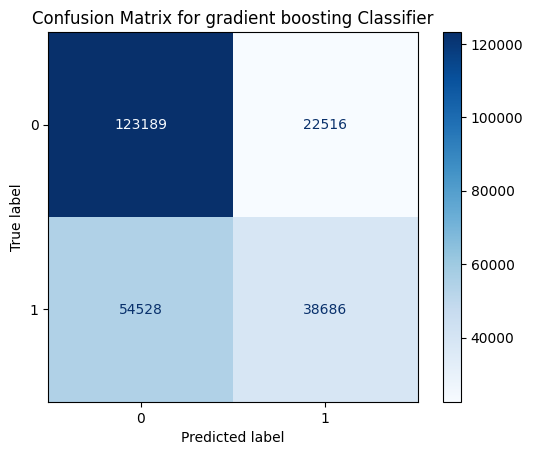

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test_binary, y_pred_gd)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=gb.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix for gradient boosting Classifier")
plt.show()

In [ ]:
accuracy = accuracy_score(y_test_binary, y_pred_gd)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.6775


In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt

#xgboost before PCA
# Convert data to DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train_binary)
dtest = xgb.DMatrix(X_test, label=y_test_binary)

# Define XGBoost parameters
params = {
    "objective": "binary:logistic",  # Binary classification
    "eval_metric": "logloss",       # Evaluation metric
    "eta": 0.1,                     # Learning rate
    "max_depth": 6,                 # Depth of tree
    "seed": 999
}

# Train the model
num_boost_round = 100
model = xgb.train(params, dtrain, num_boost_round)

# Make predictions
y_pred_prob = model.predict(dtest)  # Probabilities
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert to binary predictions

# Evaluate the model
accuracy = accuracy_score(y_test_binary, y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test_binary, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_binary, y_pred))

# Feature importance
importance = model.get_score(importance_type='weight')
importance_df = pd.DataFrame(
    list(importance.items()), columns=['Feature', 'Importance']
).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(importance_df)

# Plot feature importance
plt.figure(figsize=(10, 6))
xgb.plot_importance(model, importance_type='weight')
plt.title("Feature Importance")
plt.show()

# Calculate the percentage of predicted delays
total_flights = len(y_pred)
delayed_flights = sum(y_pred)
percentage_delayed = (delayed_flights / total_flights) * 100


print(f"Number of predictions made: {total_flights}")

KeyboardInterrupt: 

# **Bagging**

(238919, 3)
Bagged Prediction accuracy: 0.6804272577735551


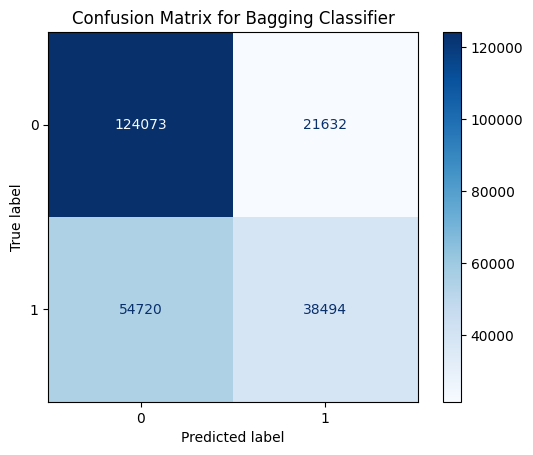

In [ ]:
from scipy.stats import mode
import numpy as np
file_path = 'Predicted_Binary_Outcomes.csv'
y_pred_xgboost = pd.read_csv(file_path)['Prediction'].values
predictions = np.array([y_pred_rf, y_pred_xgboost, y_pred_gd]).T
print(predictions.shape)
# Apply majority voting
y_pred_bagging = mode(predictions, axis=1).mode
y_pred_bagging = y_pred_bagging.flatten()
# Print the final bagged prediction
print("Bagged Prediction accuracy:", accuracy_score(y_test_binary, y_pred_bagging))
cm = confusion_matrix(y_test_binary, y_pred_bagging)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=gb.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix for Bagging Classifier")
plt.show()

# **5. PCA**

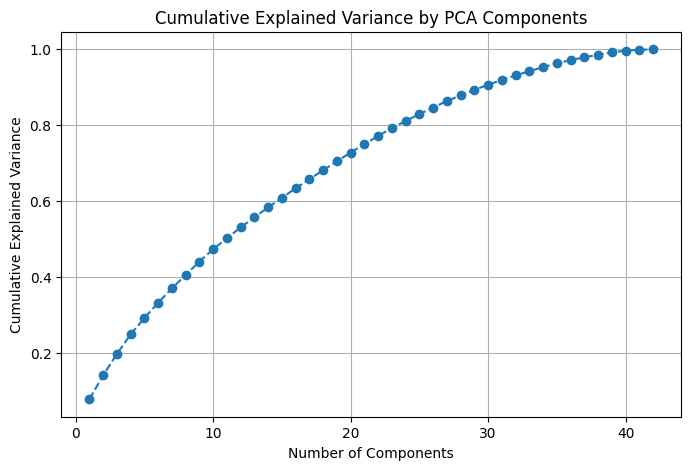

Optimal number of components: 30
Explained variance by optimal PCA: 0.906617470704423


In [ ]:
# Standardize the data
import numpy as np
scaler = StandardScaler()
data_scaled = scaler.fit_transform(X)

# Apply PCA with all components
pca_full = PCA()
pca_full.fit(data_scaled)

explained_variance_ratios = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratios)

# Plot cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid()
plt.show()

n_optimal_components = np.argmax(cumulative_variance >= 0.90) + 1
pca_optimal = PCA(n_components=n_optimal_components)
principal_components = pca_optimal.fit_transform(data_scaled)

print(f"Optimal number of components: {n_optimal_components}")
print(f"Explained variance by optimal PCA: {np.sum(pca_optimal.explained_variance_ratio_)}")

In [ ]:
import numpy as np

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=20)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Print results
print("\nExplained Variance Ratio (Training Set):")
print(explained_variance)

print("\nCumulative Explained Variance (Training Set):")
print(cumulative_variance)

print("\nShape of X_train_pca:", X_train_pca.shape)
print("Shape of X_test_pca:", X_test_pca.shape)
# principal_components = pca.fit_transform(data_scaled)
# X_pca = pd.DataFrame(data=principal_components)
# X_pca.columns = X_pca.columns.astype(str)
# explained_variance = pca.explained_variance_ratio_
# print("\nExplained Variance Ratio:")
# print(explained_variance)
# cumulative_variance = np.sum(explained_variance)
# print("\nExplained Variance in total:",cumulative_variance)



Explained Variance Ratio (Training Set):
[0.06912857 0.06145924 0.0582813  0.05469192 0.0471762  0.04386649
 0.03986668 0.03484483 0.03251618 0.03183468 0.02972431 0.02778155
 0.02650536 0.02567841 0.02493554 0.02430412 0.02395808 0.02377607
 0.02344122 0.02294579]

Cumulative Explained Variance (Training Set):
[0.06912857 0.13058781 0.18886911 0.24356103 0.29073723 0.33460372
 0.37447041 0.40931524 0.44183141 0.47366609 0.5033904  0.53117195
 0.55767731 0.58335572 0.60829126 0.63259538 0.65655346 0.68032953
 0.70377075 0.72671655]

Shape of X_train_pca: (955674, 20)
Shape of X_test_pca: (238919, 20)


# **classification models After PCA**

In [ ]:
# Logistic after PCA
model = sm.Logit(y_train_binary, X_train_pca)
result = model.fit()
y_test_pred_prob = result.predict(X_test_pca)
y_test_pred = (y_test_pred_prob > 0.5).astype(int)
accuracy = accuracy_score(y_test_binary, y_test_pred)
print(f"Logistic Test Accuracy: {accuracy:.2f}")

Optimization terminated successfully.
         Current function value: 0.669537
         Iterations 4
Logistic Test Accuracy: 0.59


In [ ]:
#xgboost after pca
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
xgb_model = XGBClassifier(
    n_estimators=100,      # Number of trees
    max_depth=6,           # Maximum depth of a tree
    learning_rate=0.1,     # Step size shrinkage
    subsample=0.8,         # Fraction of samples used for training each tree
    colsample_bytree=0.8,  # Fraction of features used for training each tree
    random_state=42        # For reproducibility
)
xgb_model.fit(X_train_pca, y_train_binary)
y_pred_xgb = xgb_model.predict(X_test_pca)


In [ ]:
# Accuracy
accuracy = accuracy_score(y_test_binary, y_pred_xgb)
print(f"Accuracy: {accuracy:.2f}")

# Classification Report
print("Classification Report:")
print(classification_report(y_test_binary, y_pred_xgb))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test_binary, y_pred_xgb))


Accuracy: 0.68
Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.85      0.76    145705
           1       0.64      0.42      0.51     93214

    accuracy                           0.68    238919
   macro avg       0.67      0.63      0.64    238919
weighted avg       0.67      0.68      0.66    238919

Confusion Matrix:
[[123566  22139]
 [ 54071  39143]]


In [ ]:
# gradient descent
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=300, max_leaf_nodes=15, random_state=2024)

gb.fit(X_train_pca, y_train_binary)

y_pred_gd = gb.predict(X_test_pca)

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-29-fa7b34a3d72d>", line 6, in <cell line: 6>
    gb.fit(X_train_pca, y_train_binary)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_gb.py", line 787, in fit
    n_stages = self._fit_stages(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_gb.py", line 883, in _fit_stages
    raw_predictions = self._fit_stage(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_gb.py", line 489, in _fit_stage
    tree.fit(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages

TypeError: object of type 'NoneType' has no len()

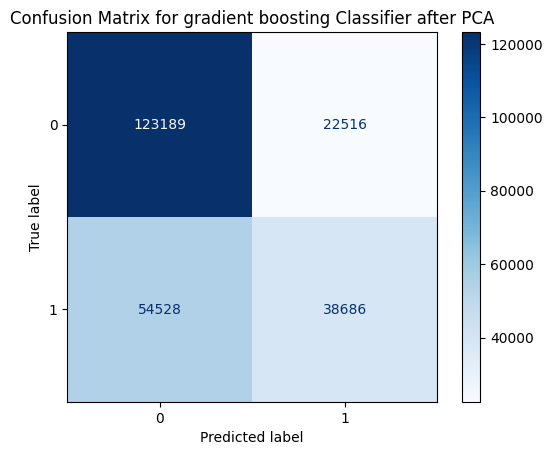

Accuracy: 0.6775


In [ ]:
cm = confusion_matrix(y_test_binary, y_pred_gd)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=gb.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix for gradient boosting Classifier after PCA")
plt.show()

accuracy = accuracy_score(y_test_binary, y_pred_gd)
print(f"Accuracy: {accuracy:.4f}")